# Finite Element Analysis - 1D Bar under Axial Loading

## 1D Bar Problem

For a bar under small deformation and linear elasticity, the governing equation and boundary conditions are:

$$
\begin{aligned}
(EAu_{,x})_{,x}+x^2 &= 0, \qquad 0<x<1, \\
u(0) &= 0, \\
EAu_{,x}(1) &= 5.
\end{aligned}
$$

Here $u_{,x}=du/dx$. The left end has prescribed zero displacement, and the right end has a prescribed axial force of 5.

This notebook will use the finite element method to analyze displacement and axial stress in a linear elastic bar, and study convergence through mesh refinement.

## Governing Equations

**Strong form (1D linear elasticity, small strain).** On the domain $0<x<L$, with $L=1$:

- Equilibrium:

$$\frac{dN}{dx}+q(x)=0,\qquad N=A\sigma$$

- Strain-displacement (small strain):

$$\varepsilon=\frac{du}{dx}$$

- Constitutive law (linear elastic):

$$\sigma=E\varepsilon,\qquad N=EA\frac{du}{dx}$$

Here $u$ is the axial displacement, $E$ is Young's modulus, $A$ is the cross-sectional area, and $N$ is the axial force. We consider constant positive $E$ and $A$.

- Boundary conditions:

$$u(0)=0,\qquad N(L)=EAu'(L)=P,\qquad P=5$$

The left end is fixed, and the right end carries an axial force $P$ in the positive $x$ direction. The distributed axial load per unit length is $q(x)=x^2$, so the governing equation is:

$$\frac{d}{dx}\left(EA\frac{du}{dx}\right)+x^2=0\quad\text{for }0<x<1.$$

**Weak form.** Find $u\in\mathcal{V}$ such that for all admissible virtual displacements $w\in\mathcal{V}_0$:

$$\int_0^L \frac{dw}{dx}\,EA\,\frac{du}{dx}\,dx
=\int_0^L w\,q(x)\,dx+w(L)P$$

Here $\mathcal{V}=\{u\in H^1(0,L):u(0)=0\}$ and $\mathcal{V}_0=\{w\in H^1(0,L):w(0)=0\}$. The space $H^1$ consists of functions whose values and first weak derivatives are square-integrable. The end force enters the weak form through $w(L)P$.

> Work in progress: the code and saved outputs below still belong to the 2D plate example and will be adapted step by step.


## 1. Import Libraries

In [148]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Physical and Material Parameters

Set Young's modulus, cross-sectional area, bar length, end load, and element settings for the 1D bar problem.

In [ ]:
# Physical and material parameters
E   = 1.0e3       # Young's modulus
A   = 1.0         # Cross-sectional area

L   = 1.0         # Length of the beam
P   = 5.0         # Applied load at the right end

ndof = 1          # Degrees of freedom per node
ncoord = 1        # Coordinates per node
eleType = 2       # Element type (quadrilateral)



## 3. Analytical Solution and Distribution Load Functions

Define the distributed axial load and analytical diaplacement and stress solutions for 1D bar problem.

In [150]:
def distributed_load(x):
    """Return the axial load per unit length at position x."""
    return x**2.0

def exact_stress(x):
    """return the exact stress at point x"""
    return (P + L**3.0/3.0 - x**3.0/3.0) / A

def exact_displacement(x):
    """return the exact displacement at point x"""
    return ((P + L**3.0/3.0) * x - x**4.0/12)/(E*A)


## 4. Mesh Generation Function

Generate a uniform mesh for the 1D bar, including node coordinates, element connectivity, and boundary conditions.

In [151]:

def get_mesh_bar(nelem_1D, L, P):
    nnode = nelem_1D + 1
    coords = np.linspace(0.0, L, nnode)
    tolerance = 1.0e-10

    connect = np.zeros((nelem_1D, 2), dtype=int)
    for i in range(nelem_1D):
        connect[i, 0] = i
        connect[i, 1] = i + 1

    fixed_nodes = np.array([0], dtype=int)
    fixed_values = np.array([0.0], dtype=float)

    nodal_forces = np.zeros(nnode, dtype=float)
    nodal_forces[-1] = P

    return nnode, coords, connect, fixed_nodes, fixed_values, nodal_forces

## 5. Shape Functions and Derivatives (Linear Bar Element)

Two-node quadrilateral element shape functions and their partial derivatives.

In [152]:
def shapefunctions_bar(xi):
    """Return 2-node bar shape functions and their derivatives with respect to xi."""
    N = np.array([
        0.5 * (1 - xi),
        0.5 * (1 + xi)
    ])
    dNdxi = 0.5 * np.array([
        -1,
        1
    ])
    return N, dNdxi
        

## 6. Element Stiffness Matrix and Force Vector

Calculate element stiffness matrix using Gauss integration.

In [153]:
def get_element_k_and_f(coord, E, A, gauss_points, gauss_weights, get_body_force):
    """Return the 1D linear bar element stiffness matrix and body-force vector."""
    ke = np.zeros((2 , 2))
    fe = np.zeros(2)

    for xi, weight_xi in zip(gauss_points, gauss_weights):

        N, dNdxi = shapefunctions_bar(xi)

        # Isoparametric mapping: x(xi) = N(xi) @ coord.
        x_gauss = N @ coord
        J = dNdxi @ coord  # dx/dxi
        if J <= 0.0:
            raise ValueError(
                "Element Jacobian must be positive."
            )
        dNdx = dNdxi / J
        
        ke += E * A * np.outer(dNdx, dNdx) * J * weight_xi
        fe += N * get_body_force(x_gauss) * J * weight_xi


    return ke, fe

## 7. Global Assembly and Solution

Assemble global stiffness matrix, apply boundary conditions, and solve the linear system.

In [154]:
def get_gauss_integration_points(number_gauss_points_in_one_direction):
    """Return Gauss-Legendre points and weights on the interval [-1, 1]."""
    if not isinstance(number_gauss_points_in_one_direction, int):
        raise TypeError("The number of Gauss points must be an integer.")
    if number_gauss_points_in_one_direction < 1:
        raise ValueError("The number of Gauss points must be at least 1.")

    return np.polynomial.legendre.leggauss(number_gauss_points_in_one_direction)


def get_global_stiffness_and_force(
    total_nodes, coords, total_element, elements, E, A, gauss_points, gauss_weights, get_body_force
):
    """Assemble the global stiffness matrix K and body-force vector F."""
    degrees_of_freedom_per_node = 1
    K = np.zeros((degrees_of_freedom_per_node * total_nodes,
                  degrees_of_freedom_per_node * total_nodes))
    F = np.zeros(degrees_of_freedom_per_node * total_nodes)

    for e in range(total_element):
        # Node IDs in the e-th element, e.g. [0, 1] 
        element = elements[e]

        # node coordinates for the e-th element
        element_coordinates = coords[element]

        # calculate the elment k and f for the e-th element
        ke, fe = get_element_k_and_f(
            element_coordinates, E, A, gauss_points, gauss_weights, get_body_force
        )

        for i in range(2):
            
            for dof_a in range(degrees_of_freedom_per_node):

                # global node id
                row = degrees_of_freedom_per_node * element[i] + dof_a

                # local node id
                local_dof_a = degrees_of_freedom_per_node * i + dof_a

                F[row] += fe[local_dof_a]

                for j in range(2):

                    for dof_b in range(degrees_of_freedom_per_node):

                        # global node id for the b-th local node
                        column = degrees_of_freedom_per_node * element[j] + dof_b

                        # local node id for the b-th local node
                        local_dof_b = degrees_of_freedom_per_node * j + dof_b

                        # local node id for the b-th local node
                        K[row, column] += ke[local_dof_a, local_dof_b]

    return K, F


def apply_traction_boundary_conditions(F, nodal_forces):
    """Apply nodal forces to the global force vector F."""
    F += nodal_forces

    return F


def apply_essential_boundary_conditions(K, F, fixed_nodes, fixed_values):
    """Apply prescribed nodal displacements to K and F."""
    for node, value in zip(fixed_nodes, fixed_values):
        F -= K[:, node] * value
        K[node, :] = 0.0
        K[:, node] = 0.0
        K[node, node] = 1.0
        F[node] = value

    return K, F

## 8. Elementwise Strain and Stress Calculation

Evaluate axial strain and stress at multiple local points in each element without averaging across element boundaries.

In [155]:
def compute_element_strain_and_stress(
    coords, elements, U, E, number_sample_points=6
):
    """Return elementwise samples without averaging shared boundaries."""
    if number_sample_points < 2:
        raise ValueError("Each element needs at least two sample points.")

    xi_samples = np.linspace(-1.0, 1.0, number_sample_points)
    total_samples = len(elements) * number_sample_points
    sample_coords = np.zeros(total_samples)
    sample_strain = np.zeros(total_samples)
    sample_stress = np.zeros(total_samples)

    sample_index = 0
    for element in elements:
        element_coords = coords[element]
        element_displacements = U[element]

        for xi in xi_samples:
            N, dNdxi = shapefunctions_bar(xi)

            # Use the same isoparametric mapping as in Part 6.
            x_sample = N @ element_coords
            J = dNdxi @ element_coords  # dx/dxi
            if J <= 0.0:
                raise ValueError(
                    "Element Jacobian must be positive."
                )
            dNdx = dNdxi / J

            sample_coords[sample_index] = x_sample
            sample_strain[sample_index] = (
                dNdx @ element_displacements
            )
            sample_stress[sample_index] = (
                E * sample_strain[sample_index]
            )
            sample_index += 1

    return sample_coords, sample_strain, sample_stress


## 9. Plotting Functions

Plot the mesh, nodal displacement, and elementwise axial stress.

In [156]:
def plot_mesh(coords, elements, title="1d Bar Mesh"):
    """Plot mesh"""
    plt.figure(figsize=(8, 2))

    # Plot elements
    for elem in elements:
        x = coords[elem]
        y = np.zeros(2)
        plt.plot(x, y, 'b-', linewidth=0.5)

    # Plot nodes
    plt.plot(coords, np.zeros_like(coords), 'ko', markersize=3)

    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_displacement_field(coords, U):
    """Plot the x- and y-displacement components at the mesh nodes."""
    plt.figure(figsize=(8, 4))

    plt.plot(coords, U, 'o-', markersize=4, label='Displacement')
    plt.xlabel('x')
    plt.ylabel('Displacement')
    plt.title('Displacement Field')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_stress_contours(sample_coords, sample_stress):
    """Plot discontinuous element stress and analytical stress."""
    plt.figure(figsize=(9, 5))

    plt.plot(
        sample_coords, sample_stress, 'o-', markersize=2.5,
        linewidth=1.0, label='FEM elementwise stress'
    )
    x_exact = np.linspace(sample_coords[0], sample_coords[-1], 300)
    plt.plot(
        x_exact, exact_stress(x_exact), 'k--', linewidth=1.5,
        label='Analytical stress'
    )
    plt.xlabel('x')
    plt.ylabel('Axial stress')
    plt.title('Elementwise Axial Stress (No Nodal Averaging)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

## 10. Main Program - Run the 1D Bar Example

In [157]:
# 1D Bar FEM Analysis

# 1. Choose the mesh density and integration rule.
number_element_in_one_direction = 20
number_gauss_points_in_one_direction = 2

# Pass the load function itself, without calling it here.
get_body_force = distributed_load

# 2. Generate nodes, connectivity, and boundary-condition data.
total_nodes, coords, elements, fixed_nodes, fixed_values, nodal_forces = (
    get_mesh_bar(number_element_in_one_direction, L, P)
)
total_element = len(elements)

# 3. Generate Gauss points and weights on [-1, 1].
gauss_points, gauss_weights = get_gauss_integration_points(
    number_gauss_points_in_one_direction
)

# 4. Assemble stiffness and the equivalent nodal distributed loads.
K, F = get_global_stiffness_and_force(
    total_nodes, coords, total_element, elements,
    E, A, gauss_points, gauss_weights, get_body_force
)

# 5. Add the prescribed concentrated force at the right end.
F = apply_traction_boundary_conditions(F, nodal_forces)

# Keep the original equations for reaction-force calculation.
K_original = K.copy()
F_original = F.copy()

# 6. Apply prescribed displacements (this modifies K and F).
K, F = apply_essential_boundary_conditions(
    K, F, fixed_nodes, fixed_values
)

# 7. Solve for the nodal displacements.
U = np.linalg.solve(K, F)

# 8. Recover reactions using the original, unconstrained equations.
residual = K_original @ U - F_original
support_reactions = residual[fixed_nodes]

# 9. Compare nodal displacements with the analytical solution.
U_exact = exact_displacement(coords)
max_nodal_error = np.max(np.abs(U - U_exact))

print("Number of nodes:", total_nodes)
print("Number of elements:", total_element)
print("Node coordinates:", coords)
print("FEM nodal displacements:", U)
print("Exact nodal displacements:", U_exact)
print("Maximum nodal displacement error:", max_nodal_error)
print("Support reactions:", support_reactions)


Number of nodes: 21
Number of elements: 20
Node coordinates: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
FEM nodal displacements: [0.00000000e+00 2.16661458e-05 4.33250000e-05 6.49578125e-05
 8.65333333e-05 1.08007812e-04 1.29325000e-04 1.50416146e-04
 1.71200000e-04 1.91582812e-04 2.11458333e-04 2.30707812e-04
 2.49200000e-04 2.66791146e-04 2.83325000e-04 2.98632812e-04
 3.12533333e-04 3.24832812e-04 3.35325000e-04 3.43791146e-04
 3.50000000e-04]
Exact nodal displacements: [0.00000000e+00 2.16661458e-05 4.33250000e-05 6.49578125e-05
 8.65333333e-05 1.08007813e-04 1.29325000e-04 1.50416146e-04
 1.71200000e-04 1.91582813e-04 2.11458333e-04 2.30707813e-04
 2.49200000e-04 2.66791146e-04 2.83325000e-04 2.98632813e-04
 3.12533333e-04 3.24832813e-04 3.35325000e-04 3.43791146e-04
 3.50000000e-04]
Maximum nodal displacement error: 1.3010426069826053e-18
Support reactions: [-0.43333333]


## 11. Visualization of the Mesh, Displacement, and Axial Stress

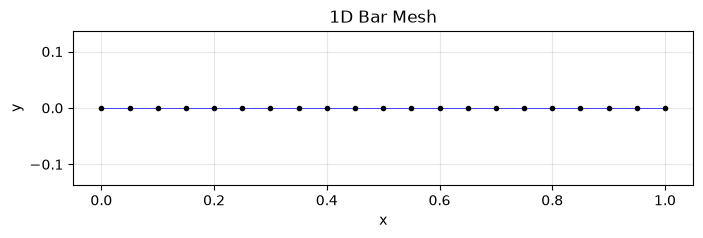

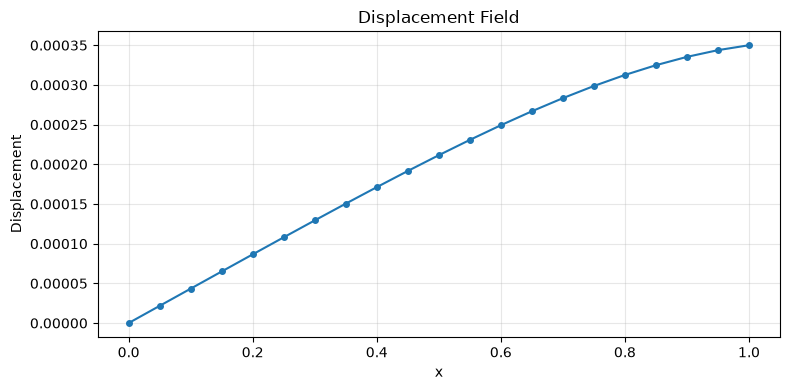

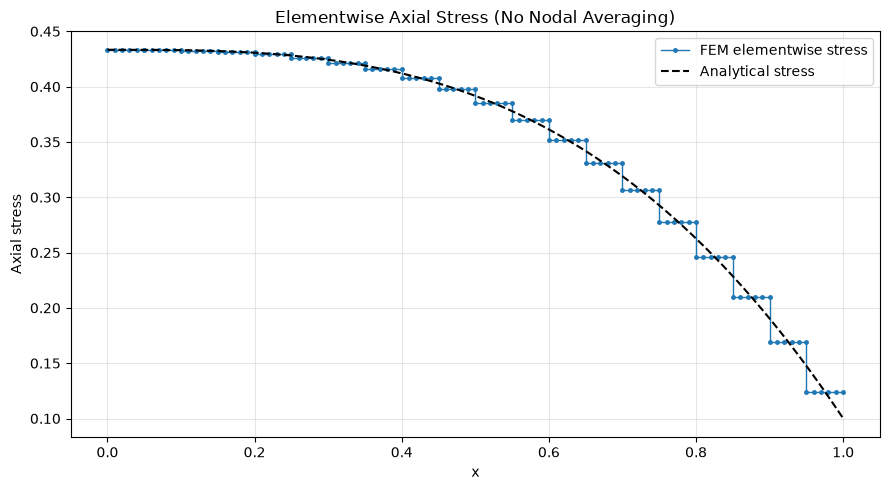

In [158]:
# Mesh visualization.
plot_mesh(coords, elements, "1D Bar Mesh")

# Axial displacement at the nodes.
plot_displacement_field(coords, U)

# Sample each element at six local points without nodal averaging.
sample_coords, sample_strain, sample_stress = (
    compute_element_strain_and_stress(
        coords, elements, U, E, number_sample_points=6
    )
)

# Discontinuous elementwise axial stress.
plot_stress_contours(sample_coords, sample_stress)

## 12. Energy Norm Error Calculation

Calculate the 1D energy norm error using element strains and the analytical solution.

In [159]:
def calculate_energy_norm_error(coords, elements, U, E, A):
    """Return the energy norm of the 1D displacement error."""
    # Four points integrate the squared cubic strain error exactly.
    gauss_points, gauss_weights = get_gauss_integration_points(4)
    enorm2 = 0.0

    for element in elements:
        element_coords = coords[element]
        element_displacements = U[element]

        for xi, weight in zip(gauss_points, gauss_weights):
            N, dNdxi = shapefunctions_bar(xi)

            # Use the same isoparametric mapping as in Parts 6 and 8.
            x_gauss = N @ element_coords
            J = dNdxi @ element_coords  # dx/dxi
            if J <= 0.0:
                raise ValueError(
                    "Element Jacobian must be positive."
                )
            dNdx = dNdxi / J

            # Use the raw element strain, not the averaged nodal strain.
            strain_fem = dNdx @ element_displacements
            # exact_stress uses the same global A, L and P as the main program.
            strain_exact = exact_stress(x_gauss) / E
            strain_error = strain_fem - strain_exact

            enorm2 += E * A * strain_error**2 * J * weight

    return np.sqrt(enorm2)


## 13. Main Program 2 - Mesh Convergence Study

Perform calculations with different mesh densities and analyze convergence rate.

In [160]:
# Refine the 1D mesh while keeping the material and loading unchanged.
refinements = [4, 8, 16, 32]
h_vals = []
err_vals = []
study_gauss_points, study_gauss_weights = get_gauss_integration_points(2)

print("1D Bar Energy Norm Error Analysis")
print("-" * 60)

for nelem in refinements:
    # Separate study variables preserve the Part 10 solution for plotting.
    study_nnode, study_coords, study_elements, study_fixed_nodes, study_fixed_values, study_nodal_forces = (
        get_mesh_bar(nelem, L, P)
    )
    h = L / nelem

    study_K, study_F = get_global_stiffness_and_force(
        study_nnode, study_coords, nelem, study_elements,
        E, A, study_gauss_points, study_gauss_weights, distributed_load
    )
    study_F = apply_traction_boundary_conditions(study_F, study_nodal_forces)
    study_K, study_F = apply_essential_boundary_conditions(
        study_K, study_F, study_fixed_nodes, study_fixed_values
    )
    study_U = np.linalg.solve(study_K, study_F)

    # Part 12 uses four-point integration for the squared strain error.
    error = calculate_energy_norm_error(
        study_coords, study_elements, study_U, E, A
    )
    h_vals.append(h)
    err_vals.append(error)

    print(f"Elements = {nelem:3d}, h = {h:.6f}, energy error = {error:.8e}")


1D Bar Energy Norm Error Analysis
------------------------------------------------------------
Elements =   4, h = 0.250000, energy error = 1.00293024e-03
Elements =   8, h = 0.125000, energy error = 5.08096357e-04
Elements =  16, h = 0.062500, energy error = 2.54878348e-04
Elements =  32, h = 0.031250, energy error = 1.27542984e-04


## 14. Plot Convergence Curve

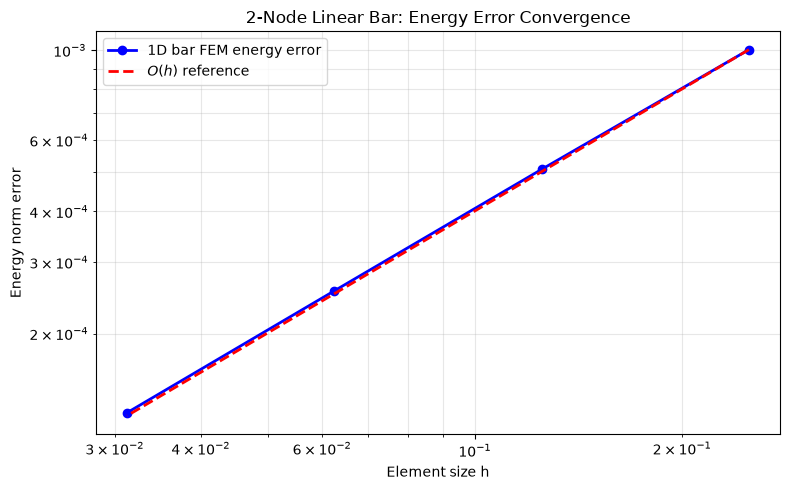


Convergence rates (expected to approach 1):
------------------------------------------------------------
Elements:   4 ->   8, rate = 0.9810
Elements:   8 ->  16, rate = 0.9953
Elements:  16 ->  32, rate = 0.9988


In [161]:
# Plot the energy error against element size on logarithmic axes.
plt.figure(figsize=(8, 5))
plt.loglog(h_vals, err_vals, 'bo-', markersize=6, linewidth=2,
           label='1D bar FEM energy error')

# Scale the first-order reference line to the coarsest-mesh error.
C = err_vals[0] / h_vals[0]
h_ref = np.array([h_vals[0], h_vals[-1]])
plt.loglog(h_ref, C * h_ref, 'r--', linewidth=2,
           label=r'$O(h)$ reference')

plt.xlabel('Element size h')
plt.ylabel('Energy norm error')
plt.title('2-Node Linear Bar: Energy Error Convergence')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nConvergence rates (expected to approach 1):")
print("-" * 60)
rates = []
for i in range(len(h_vals) - 1):
    rate = np.log(err_vals[i + 1] / err_vals[i]) / np.log(h_vals[i + 1] / h_vals[i])
    rates.append(rate)
    print(
        f"Elements: {refinements[i]:3d} -> {refinements[i + 1]:3d}, "
        f"rate = {rate:.4f}"
    )
